# (02) df: beta

**Motivation**: Device = ```cuda:3``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
from analysis.eval import sparse_score
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

## Device

In [2]:
device_idx = 3
device = f'cuda:{device_idx}'

from analysis.final import sort_fits, analyze_fits

## Load, make df

### Fit names

In [3]:
fits, fits_st, fits_etc = sort_fits()
len(fits), len(fits_st), len(fits_etc)

(7, 0, 120)

### df

In [4]:
def accept_fn(name):
    archi = name.split('-')[1]
    accept = (
        archi in ['<lin|lin>', '<conv+b|lin>']
        and 'poisson-' in name
        and '-vH16-' in name
    )
    return accept


fits = sorted(filter(accept_fn, fits))
fits_etc = sorted(filter(accept_fn, fits_etc))
print(f"# fits: {len(fits)}  ———  # fits_etc: {len(fits_etc)}")

# fits: 1  ———  # fits_etc: 120

In [5]:
%%time

kws = dict(device=device, analysis_mode='main')
df = analyze_fits(fits_etc, **kws)

save_obj(
    obj=df,
    file_name=f'df_beta_main_({now()})',
    save_dir=tmp_dir,
    verbose=True,
    mode='df',
)

100%|█████████████████████████████████████████| 120/120 [01:43<00:00,  1.15it/s]

[PROGRESS] 'df_beta_main_(2024_12_02).df' saved at
/home/hadi/Dropbox/git/jb-vae/tmp
CPU times: user 58min 34s, sys: 2min 36s, total: 1h 1min 11s
Wall time: 1min 44s


In [6]:
for sparse_key in ['lifetime', 'population']:
    kws = dict(
        device=device,
        analysis_mode='sparse',
        sparse_key=sparse_key,
    )
    df = analyze_fits(fits_etc, **kws)

    save_obj(
        obj=df,
        file_name=f'df_beta_{sparse_key}_({now()})',
        save_dir=tmp_dir,
        verbose=True,
        mode='df',
    )

100%|█████████████████████████████████████████| 120/120 [01:40<00:00,  1.19it/s]


[PROGRESS] 'df_beta_lifetime_(2024_12_02).df' saved at
/home/hadi/Dropbox/git/jb-vae/tmp


100%|█████████████████████████████████████████| 120/120 [01:44<00:00,  1.15it/s]


[PROGRESS] 'df_beta_population_(2024_12_02).df' saved at
/home/hadi/Dropbox/git/jb-vae/tmp


## Load for analysis

In [7]:
df_beta_lifetime = pjoin(tmp_dir, 'df_beta_lifetime_(2024_12_02).df')
df_beta_lifetime = pd.read_pickle(df_beta_lifetime)

In [8]:
df_beta_lifetime.pivot_table(
    values='lifetime',
    index=['enc_type', 'n_dims'],
    columns='kl_beta',
)

,kl_beta,0.001,0.010,0.200,0.400,0.600,0.800,1.000,1.200,2.000,3.000,4.000,5.000
enc_type,n_dims,,,,,,,,,,,,
conv,512,0.840751,0.844315,0.834348,0.861793,0.890371,0.919102,0.942705,0.961863,0.988347,0.994208,0.996249,0.995974
lin,512,0.366565,0.327579,0.414469,0.515815,0.620669,0.719455,0.798561,0.856126,0.965995,0.993746,0.997027,0.997641


In [9]:
df_beta_lifetime.loc[df_beta_lifetime['enc_type'] == 'lin'].pivot_table(
    values='lifetime',
    index='n_dims',
    columns='kl_beta',
)

kl_beta,0.001,0.010,0.200,0.400,0.600,0.800,1.000,1.200,2.000,3.000,4.000,5.000
n_dims,,,,,,,,,,,,
512,0.366565,0.327579,0.414469,0.515815,0.620669,0.719455,0.798561,0.856126,0.965995,0.993746,0.997027,0.997641


In [10]:
df_beta_main = pjoin(tmp_dir, 'df_beta_main_(2024_12_02).df')
df_beta_main = pd.read_pickle(df_beta_main)

In [11]:
df_beta_main['type'].unique()

array(['poisson-b0.001', 'poisson-b0.01', 'poisson-b0.2', 'poisson-b0.4',
       'poisson-b0.6', 'poisson-b0.8', 'poisson-b1.2', 'poisson',
       'poisson-b2', 'poisson-b3', 'poisson-b4', 'poisson-b5'],
      dtype=object)

In [12]:
df_beta_main.loc[df_beta_main['enc_type'] == 'lin'].pivot_table(
    values='mse',
    index='n_dims',
    columns='kl_beta',
)

kl_beta,0.001,0.010,0.200,0.400,0.600,0.800,1.000,1.200,2.000,3.000,4.000,5.000
n_dims,,,,,,,,,,,,
512,9.042665,20.511448,70.057968,95.014786,112.471535,125.950485,136.741928,145.855835,171.066803,185.171478,188.93428,189.845474


In [13]:
df_beta_main.loc[df_beta_main['enc_type'] == 'lin'].pivot_table(
    values='mse_map',
    index='n_dims',
    columns='kl_beta',
)

kl_beta,0.001,0.010,0.200,0.400,0.600,0.800,1.000,1.200,2.000,3.000,4.000,5.000
n_dims,,,,,,,,,,,,
512,1.414432,3.628213,28.563732,51.629326,71.337326,88.094589,102.493324,115.17466,152.754013,177.088303,185.349991,188.060028


In [14]:
df_beta_main.loc[df_beta_main['enc_type'] == 'lin'].pivot_table(
    values='active',
    index='n_dims',
    columns='kl_beta',
)

kl_beta,0.001,0.010,0.200,0.400,0.600,0.800,1.000,1.200,2.000,3.000,4.000,5.000
n_dims,,,,,,,,,,,,
512,0.821094,0.961719,0.994141,0.992188,0.986328,0.987891,0.989062,0.989453,0.994531,0.951953,0.474219,0.296484


In [27]:
df_beta_main.shape, df_beta_lifetime.shape

((120, 21), (61440, 13))

In [35]:
# mse
df_selec_main = df_beta_main.loc[
    (df_beta_main['n_dims'] == 512) & 
    (df_beta_main['enc_type'].isin(['lin', 'conv']))
]
df_selec_main.drop(
    columns=[
        'checkpoint', 'timestamp', 'dataset', 'dec_type', 'active', 'kl', 'kl_diag',
        'temp_anneal', 'temp_start', 'temp_stop', 'hard_fwd'],
    inplace=True,
)
# lifetime
df_selec_lifetime = df_beta_lifetime.loc[
    (df_beta_lifetime['n_dims'] == 512) & 
    (df_beta_lifetime['enc_type'].isin(['lin', 'conv']))
]
df_selec_lifetime = df_selec_lifetime.groupby(
    ['enc_type', 'kl_beta', 'seed']).mean(numeric_only=True)
df_selec_lifetime = df_selec_lifetime['lifetime'].reset_index()

df_selec_main.shape, df_selec_lifetime.shape

((120, 10), (120, 4))

In [36]:
df_selec_main

,type,enc_type,n_dims,seed,kl_beta,n_params,method,mse,mse_map,nelbo
0,poisson-b0.001,conv,512,1,0.001,1405596,mc,56.653316,48.837059,3194.008301
1,poisson-b0.001,conv,512,2,0.001,1405596,mc,64.317390,57.209873,2637.829346
2,poisson-b0.001,conv,512,3,0.001,1405596,mc,45.341522,38.044823,3780.258545
3,poisson-b0.001,conv,512,4,0.001,1405596,mc,47.391064,39.786072,3488.910889
4,poisson-b0.001,conv,512,5,0.001,1405596,mc,48.317738,40.606983,4740.405273
...,...,...,...,...,...,...,...,...,...,...
115,poisson-b5,lin,512,1,5.000,262656,mc,189.895233,188.106461,190.281311
116,poisson-b5,lin,512,2,5.000,262656,mc,189.730225,188.013702,190.114075
117,poisson-b5,lin,512,3,5.000,262656,mc,189.882156,188.062012,190.271194
118,poisson-b5,lin,512,4,5.000,262656,mc,189.809158,188.094437,190.202560


In [39]:
looper = itertools.product(
    sorted(df_selec_main['enc_type'].unique()),
    sorted(df_selec_main['kl_beta'].unique()),
    sorted(df_selec_main['seed'].unique()),
)

df2p = collections.defaultdict(list)

for e, b, s in looper:
    mse_map = df_selec_main.loc[
        (df_selec_main['seed'] == s) &
        (df_selec_main['kl_beta'] == b) &
        (df_selec_main['enc_type'] == e),
        'mse_map',
    ].item()
    lifetime = df_selec_lifetime.loc[
        (df_selec_lifetime['seed'] == s) &
        (df_selec_lifetime['kl_beta'] == b) &
        (df_selec_lifetime['enc_type'] == e),
        'lifetime',
    ].item()
    
    vals = {
        'type': 'poisson',
        'type+b': 'poisson' if b == 1.0
        else f"poisson-{b:0.2g}",
        'seed': s,
        'beta': b,
        'enc_type': e,
        'mse_map': mse_map,
        'lifetime': lifetime,
    }
    for k, v in vals.items():
        df2p[k].append(v)

df2p = pd.DataFrame(df2p)

In [41]:
def get_palette():
	# poisson
	betas = [
		0.001, 0.01, 0.2, 0.4, 0.6, 0.8,
		1.0, 1.2, 2.0, 3.0, 4.0, 5.0,
	]
	colors = sns.color_palette(
		'crest', n_colors=len(betas))
	palette = {
		'poisson' if b == 1.0 else f"poisson-{b:0.2g}":
			c for b, c in zip(betas, colors)
	}
	palette_beta = {
		b: c for b, c in zip(betas, colors)
	}
	# gaussian
	items = ['-relu', '', '-exp']
	colors = sns.color_palette(
		'flare', n_colors=len(items))
	palette.update({
		'gaussian' + k: c for k, c
		in zip(items, colors)
	})
	# laplace, categorical
	muted = sns.color_palette('muted')
	palette.update({
		'laplace': muted[2],
		'categorical': muted[5],
	})
	# lca, ista
	palette.update({
		'lca': '#6f6f6f',
		'ista': '#aeaeae',
	})
	# lambda (lca)
	lamb = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.7, 1.0]
	colors = sns.cubehelix_palette(n_colors=len(lamb))
	palette_lamb = {
		lamb: c for lamb, c in zip(lamb, colors)
	}
	return palette, palette_beta, palette_lamb

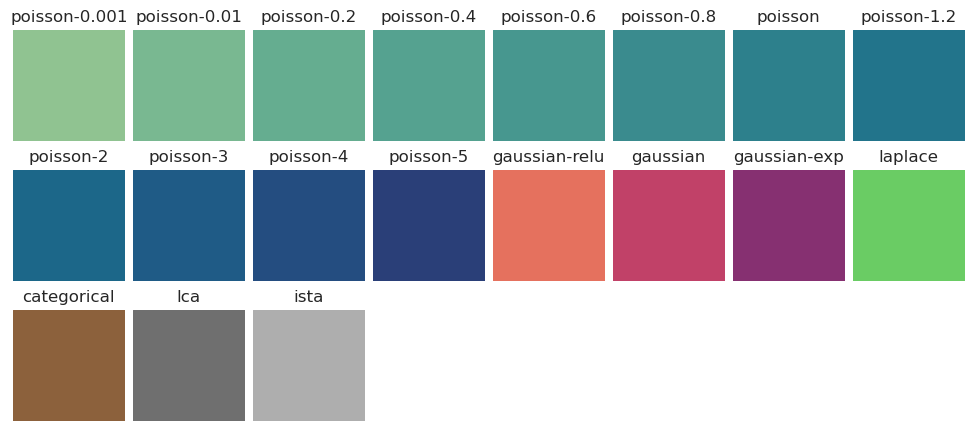

In [43]:
palette, palette_beta, palette_lamb = get_palette()
show_palette(palette)

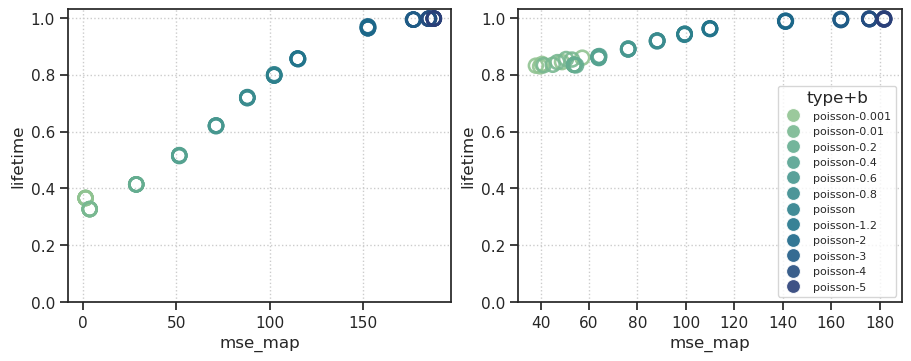

In [58]:
fig, axes = create_figure(1, 2, figsize=(9, 3.5))
for i, enc in enumerate(['lin', 'conv']):
    ax = axes.flat[i]
    sns.scatterplot(
        data=df2p.loc[df2p['enc_type'] == enc],
        x='mse_map',
        y='lifetime',
        hue='type+b',
        palette=palette,
        alpha=0.9,
        s=100,
        ax=ax,
    )
    for artist in ax.collections:
        c = artist.get_facecolor()
        artist.set_edgecolor(c)
        artist.set_facecolor('none')
        artist.set_lw(1.9)
    ax.set_ylim(bottom=0, top=1.03)
    if i == 0:
        move_legend(ax)
    else:
        sns.move_legend(ax, loc='lower right', fontsize=8)
    ax.grid()
plt.show()

In [60]:
selected_betas = [
    0.01, 0.2, 0.4, 0.6, 0.8,
    1.0, 1.2, 2.0, 3.0, 5.0,
]

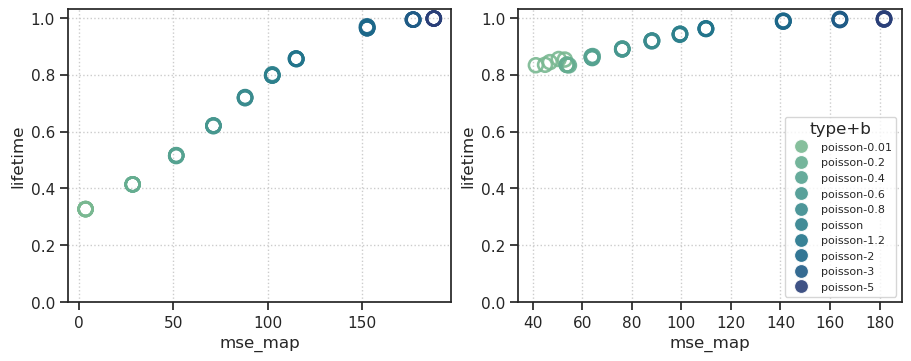

In [61]:
fig, axes = create_figure(1, 2, figsize=(9, 3.5))
for i, enc in enumerate(['lin', 'conv']):
    ax = axes.flat[i]
    _df = df2p.loc[
        (df2p['beta'].isin(selected_betas)) &
        (df2p['enc_type'] == enc)
    ]
    sns.scatterplot(
        data=_df,
        x='mse_map',
        y='lifetime',
        hue='type+b',
        palette=palette,
        alpha=0.9,
        s=100,
        ax=ax,
    )
    for artist in ax.collections:
        c = artist.get_facecolor()
        artist.set_edgecolor(c)
        artist.set_facecolor('none')
        artist.set_lw(1.9)
    ax.set_ylim(bottom=0, top=1.03)
    if i == 0:
        move_legend(ax)
    else:
        sns.move_legend(ax, loc='lower right', fontsize=8)
    ax.grid()
plt.show()

In [53]:
save_obj(
    obj=df2p,
    file_name=f'df2p_poisson_beta_(now())',
    save_dir=tmp_dir,
    mode='df',
)

[PROGRESS] 'df2p_poisson_beta_(now()).df' saved at
/home/hadi/Dropbox/git/jb-vae/tmp


## Fit sigmoid

In [152]:
selected_betas = [
    0.01, 0.2, 0.4, 0.6, 0.8,
    1.0, 1.2, 4.0,
]
enc = 'conv'

In [153]:
df2p_convbeta = df2p.loc[
    (df2p['enc_type'] == enc) &
    (df2p['beta'].isin(selected_betas))
]
df2p_convbeta = df2p_convbeta.groupby(by=['beta']).mean(
    numeric_only=True).drop(columns=['seed']).reset_index()

In [154]:
df2p_convbeta

,beta,mse_map,lifetime
0,0.01,47.343404,0.844315
1,0.20,54.011217,0.834348
2,0.40,63.992791,0.861793
3,0.60,76.148015,0.890371
4,0.80,88.115875,0.919102
5,1.00,99.448260,0.942705
6,1.20,109.912793,0.961863
7,4.00,175.741937,0.996249


In [155]:
save_obj(
    obj=df2p_convbeta,
    file_name='df2p_poisson_conv_beta',
    save_dir=pjoin(tmp_dir, 'pvae_results'),
    mode='df',
)

[PROGRESS] 'df2p_poisson_conv_beta.df' saved at
/home/hadi/Dropbox/git/jb-vae/tmp/pvae_results


Fitted parameters:
L = 0.182, x0 = 83.354, k = 0.056, y0 = 0.815

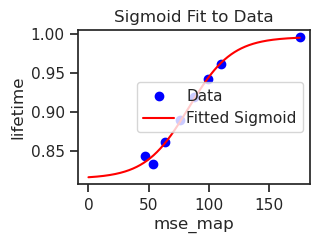

In [160]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Example data (replace these with your actual data)
x_data = df2p_convbeta['mse_map'].values
y_data = df2p_convbeta['lifetime'].values

# Define the sigmoid function
def sigmoid(x, L, x0, k, y0):
    return L / (1 + np.exp(-k * (x - x0))) + y0

# Initial guesses for parameters
L_guess = max(y_data) - min(y_data)  # Range of y
x0_guess = np.median(x_data)        # Midpoint of x
k_guess = 0.1                       # Initial steepness guess
y0_guess = min(y_data)              # Minimum y value

p0 = [L_guess, x0_guess, k_guess, y0_guess]  # Initial parameter guess

# Fit the curve
popt, pcov = curve_fit(sigmoid, x_data, y_data, p0)

# Extract the fitted parameters
L, x0, k, y0 = popt

print(f"Fitted parameters:\nL = {L:.3f}, x0 = {x0:.3f}, k = {k:.3f}, y0 = {y0:.3f}")

# Plot the data and the fitted curve
x_fit = np.linspace(0, max(x_data), 500)
y_fit = sigmoid(x_fit, *popt)

plt.scatter(x_data, y_data, label='Data', color='blue')
plt.plot(x_fit, y_fit, label='Fitted Sigmoid', color='red')
plt.xlabel('mse_map')
plt.ylabel('lifetime')
plt.legend()
plt.title('Sigmoid Fit to Data')
plt.show()


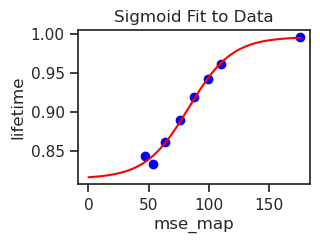

In [165]:
x_fit = np.linspace(0, max(x_data), 500)
y_fit = sigmoid_beta_conv(x_fit)

plt.scatter(x_data, y_data, label='Data', color='blue')
plt.plot(x_fit, y_fit, label='Fitted Sigmoid', color='red')
plt.xlabel('mse_map')
plt.ylabel('lifetime')
plt.title('Sigmoid Fit to Data')
plt.show()

In [176]:
df2p_new_conv = df2p.loc[
    (df2p['enc_type'] == 'conv') &
    (df2p['beta'] == 1.0)
]
df2p_new_conv = df2p_new_conv.drop(columns=['type+b', 'beta', 'enc_type'])

In [177]:
df2p_new_conv

,type,seed,mse_map,lifetime
30,poisson,1,99.520309,0.943217
31,poisson,2,99.378944,0.940353
32,poisson,3,99.456566,0.943551
33,poisson,4,99.473259,0.944062
34,poisson,5,99.412224,0.942340


In [178]:
save_obj(
    obj=df2p_new_conv,
    file_name='df2p_new_conv',
    save_dir=pjoin(tmp_dir, 'pvae_results'),
    mode='df',
)

[PROGRESS] 'df2p_new_conv.df' saved at
/home/hadi/Dropbox/git/jb-vae/tmp/pvae_results
